Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

Load Clean Dataset

In [ ]:
df = pd.read_csv("bank_customer_cleaned.csv")

df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


Separate Features and Target

In [ ]:
X = df.drop("Exited", axis=1)
y = df["Exited"]

Check Categorical Columns

In [ ]:
X.select_dtypes(include="object").columns

Index(['Geography', 'Gender', 'Card Type'], dtype='object')

Convert Categories into Numbers

In [ ]:
X = pd.get_dummies(
    X,
    columns=["Geography","Gender","Card Type"],
    drop_first=True
)
#Check dataset
X.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Complain,Satisfaction Score,Point Earned,Geography_Germany,Geography_Spain,Gender_Male,Card Type_GOLD,Card Type_PLATINUM,Card Type_SILVER
0,619,42,2,0.00,1,1,1,101348.88,1,2,464,False,False,False,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,1,3,456,False,True,False,False,False,False
2,502,42,8,159660.80,3,1,0,113931.57,1,3,377,False,False,False,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,5,350,False,False,False,True,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,5,425,False,True,False,True,False,False


Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)
#Check Shape
print(X_train.shape)
print(X_test.shape)

(8000, 17)
(2000, 17)


Feature Scaling

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

**LOGISTIC REGRESSION**

Train Model

In [ ]:
lr_model = LogisticRegression(
    random_state=42
)

lr_model.fit(X_train,y_train)

LogisticRegression(random_state=42)

Prediction

In [ ]:
lr_pred = lr_model.predict(X_test)

Prediction Probabilities

In [ ]:
lr_prob = lr_model.predict_proba(X_test)[:,1]

Accuracy

In [ ]:
print("Accuracy : ",accuracy_score(y_test,lr_pred))

Accuracy :  0.999


Precision

In [ ]:
print("Precision : ",precision_score(y_test,lr_pred))

Precision :  0.9974554707379135


Recall

In [ ]:
print("Recall : ",recall_score(y_test,lr_pred))

Recall :  0.9974554707379135


F1 Score

In [ ]:
print("F1 Score : ",f1_score(y_test,lr_pred))

F1 Score :  0.9974554707379135


ROC-AUC Score

In [ ]:
roc = roc_auc_score(y_test,lr_prob)
print("ROC AUC :",roc)

ROC AUC : 0.9996231499910538


Confusion Matrix

In [ ]:
cm = confusion_matrix(y_test,lr_pred)
print(cm)

[[1606    1]
 [   1  392]]


Classification Report

In [ ]:
print(classification_report(y_test,lr_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1607
           1       1.00      1.00      1.00       393

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



ROC Curve

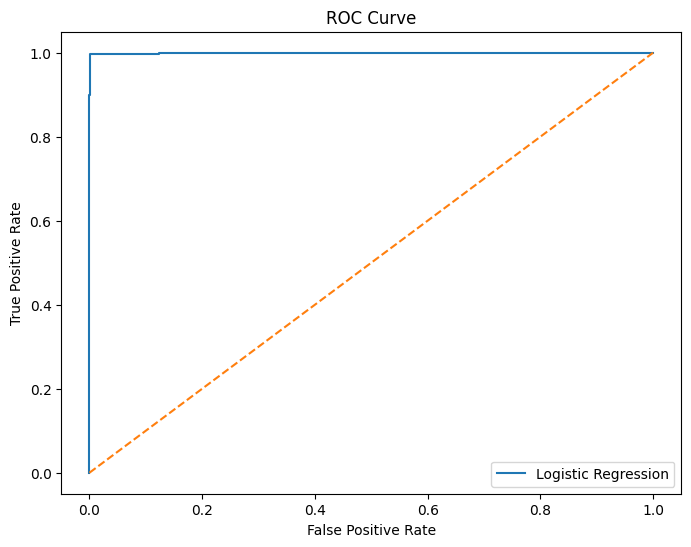

In [ ]:
fpr,tpr,thresholds = roc_curve(
    y_test,
    lr_prob
)

plt.figure(figsize=(8,6))

plt.plot(fpr,tpr,label="Logistic Regression")

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

**RANDOM FOREST**

Train Model

In [ ]:
rf_model = RandomForestClassifier(
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

RandomForestClassifier(random_state=42)

Prediction

In [ ]:
rf_pred = rf_model.predict(X_test)

Prediction Probability

In [ ]:
rf_prob = rf_model.predict_proba(X_test)[:,1]

Accuracy

In [ ]:
print("Accuracy :",accuracy_score(y_test,rf_pred))

Accuracy : 0.999


Precision

In [ ]:
print("Precision :",precision_score(y_test,rf_pred))

Precision : 0.9974554707379135


Recall

In [ ]:
print("Recall :",recall_score(y_test,rf_pred))

Recall : 0.9974554707379135


F1 Score

In [ ]:
print("F1 Score :",f1_score(y_test,rf_pred))

F1 Score : 0.9974554707379135


ROC-AUC

In [ ]:
roc = roc_auc_score(
    y_test,
    rf_prob
)

print("ROC AUC :",roc)

ROC AUC : 0.998133167392657


Confusion Matrix

In [ ]:
cm = confusion_matrix(
    y_test,
    rf_pred
)

print(cm)

[[1606    1]
 [   1  392]]


Classification Report

In [ ]:
print(classification_report(
    y_test,
    rf_pred
))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1607
           1       1.00      1.00      1.00       393

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



ROC Curve

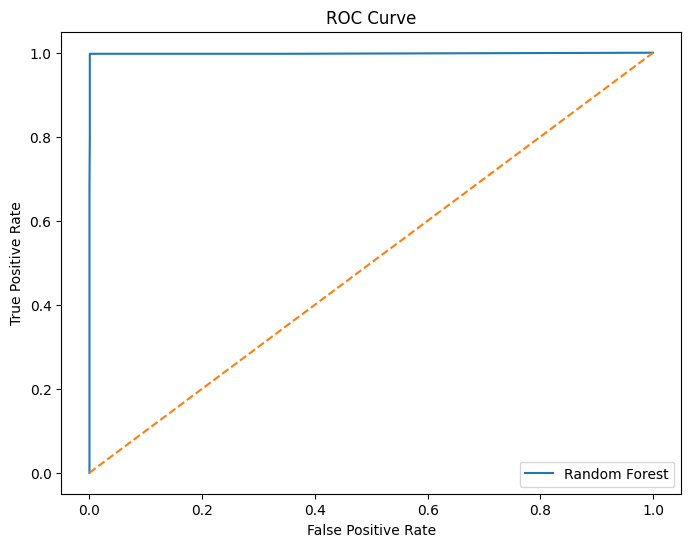

In [ ]:
fpr,tpr,thresholds = roc_curve(
    y_test,
    rf_prob
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label="Random Forest"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

**Feature Importance**

In [ ]:
importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":rf_model.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
8,Complain,0.825072
1,Age,0.065798
4,NumOfProducts,0.042478
6,IsActiveMember,0.012948
3,Balance,0.011474
0,CreditScore,0.007763
11,Geography_Germany,0.007479
7,EstimatedSalary,0.007362
10,Point Earned,0.006568
2,Tenure,0.003969


Plot Feature Importance

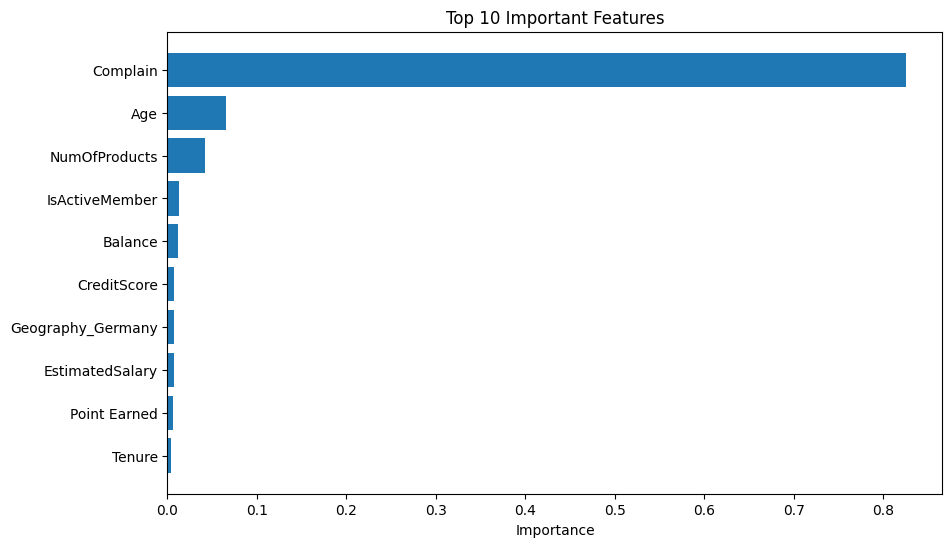

In [ ]:
plt.figure(figsize=(10,6))

plt.barh(

    importance["Feature"][:10],

    importance["Importance"][:10]

)

plt.gca().invert_yaxis()

plt.xlabel("Importance")
plt.title("Top 10 Important Features")

plt.show()

**Compare Models**

In [ ]:
results = pd.DataFrame({

    "Model":[

        "Logistic Regression",

        "Random Forest"

    ],

    "Accuracy":[

        accuracy_score(y_test,lr_pred),

        accuracy_score(y_test,rf_pred)

    ],

    "Precision":[

        precision_score(y_test,lr_pred),

        precision_score(y_test,rf_pred)

    ],

    "Recall":[

        recall_score(y_test,lr_pred),

        recall_score(y_test,rf_pred)

    ],

    "F1 Score":[

        f1_score(y_test,lr_pred),

        f1_score(y_test,rf_pred)

    ],

    "ROC AUC":[

        roc_auc_score(y_test,lr_prob),

        roc_auc_score(y_test,rf_prob)

    ]

})

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.999,0.997455,0.997455,0.997455,0.999623
1,Random Forest,0.999,0.997455,0.997455,0.997455,0.998133
